# Project of Zomato 

# QUESTION IS THE ZOMATO PROJECT
) What type of restaurant do the majority of customers order from?

2 How many votes has each type of restaurant received from customers?

3) What are the ratings that the majority of restaurants have received? A

4)Zomato has observed that most couples order most of their food online. What average spending on each order?

5) Which mode (online or offline) has received the maximum rating?

6) Which type of restaurant received more offline orders, so that Zomato can customers with some good offers?

In [53]:
# Import Library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# data import
data = pd.read_csv("Zomato data .csv")
data

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


#  What type of restaurant do the majority of customers order from?

In [55]:
# convert the data type of columns rate
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

data['rate'] = data['rate'].apply(handleRate)
print(data.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [56]:
# checking the any null set 
data.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# Type of Resturant

In [58]:
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


C:\Users\deppa\AppData\Local\Temp\ipykernel_14124\255384219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['listed_in(type)'],palette = c)


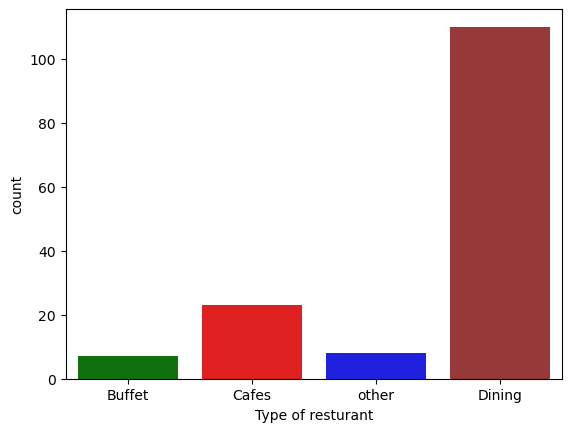

In [59]:
# finding Maximum use  type of resturat
c = ['green','red','blue','brown']
sns.countplot(x=data['listed_in(type)'],palette = c)
plt.xlabel("Type of resturant")
plt.show()

#  How many votes has each type of restaurant received from customers?

In [60]:
# checking the maximum rateted of resturant 
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


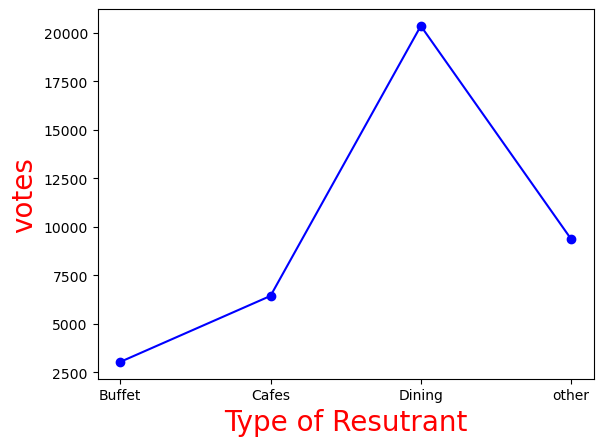

In [67]:
grouped_data = data.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
#result.plot(kind='line', color="green", marker='o', legend=False)
plt.plot(result,c="blue",marker='o')
plt.xlabel("Type of Resutrant",c="red",size=20)
plt.ylabel("votes",c="red",size=20)
plt.show()

 Conclusion  - dining  resturant has recived maximum votes

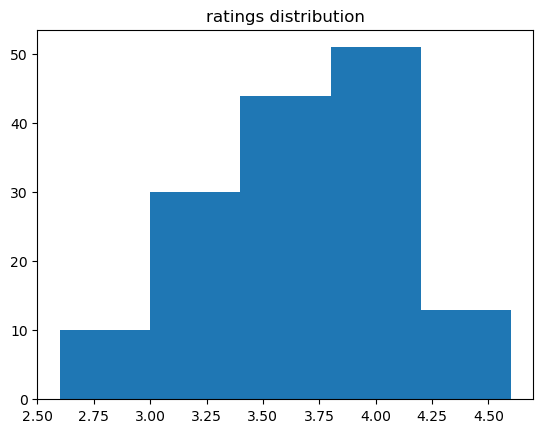

In [69]:
# type of rating under 5 star
plt.hist(data['rate'],bins = 5)
plt.title("ratings distribution")
plt.show()

conclusion - the majority resturant recievd  rating from 3.5 to 4

C:\Users\deppa\AppData\Local\Temp\ipykernel_14124\4119679858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = couple_data, palette = "prism")


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

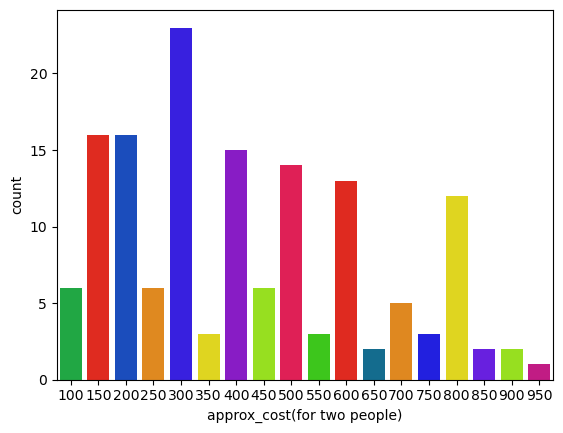

In [73]:
# Average order spending in returant
couple_data = data['approx_cost(for two people)']
sns.countplot(x = couple_data, palette = "prism")

conclusion - The majority of couple prefer the resturants with an approximate cost of 300 rupesd

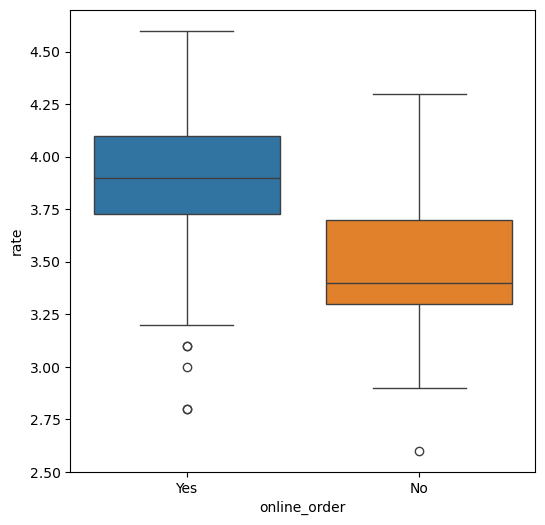

In [76]:
# online mode or offline mode  which mode or rating is high
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y = 'rate', data =data, hue='online_order')
plt.show()

conclusion - the majority of rating is online is high rating compareing the offline

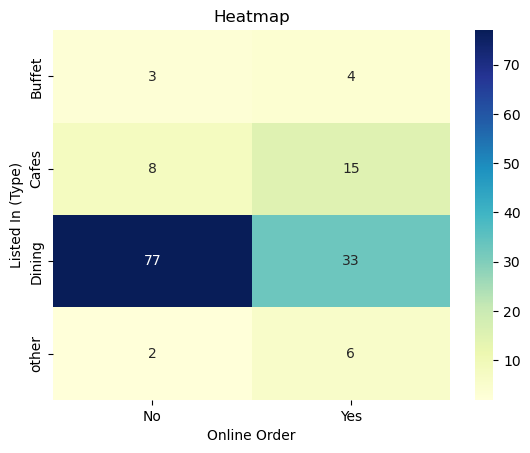

In [77]:
# checking  the resturant hom many people odering the food online or offline eating food
pivot_table = data.pivot_table(index='listed_in(type)',
             columns='online_order',
             aggfunc ='size',
             fill_value=0
)
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()


In [ ]:
conclusion - dining resturant primarly accept oflline order ,
where as cafes primarily recieve online order .
this suggests the client prefered order in person at resturant online ordering at cafes